In [1]:
import numpy as np 
import pandas as pd

In [2]:
df = pd.read_csv(r"D:\ML\DataSet\titanic_day33_only.csv")

In [4]:
df.head()       #in the number column we have denoted the alone traveller with 'A' 

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


first we are going to work on the "number" column

In [5]:
df['number'].unique()       #this will tell about all the unique elements present in the column

<StringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str

Text(0.5, 1.0, 'Passengers travelling with : ')

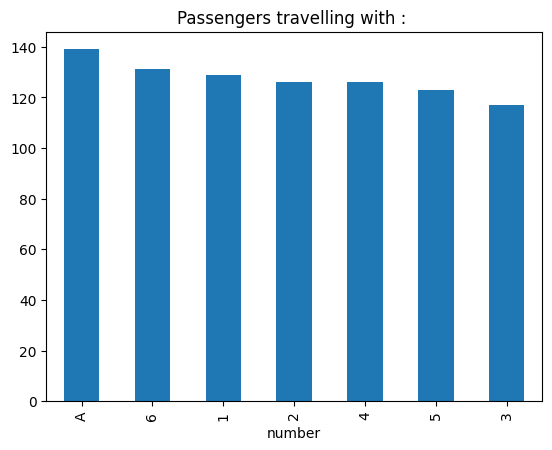

In [7]:
fig = df['number'].value_counts().plot.bar()        #this is a way to plot bar graph without using the matplotlib
fig.set_title('Passengers travelling with : ')

now , if within a column we have both numerical and categorical data then we use the following code : 

In [10]:
#extract the numerical part

df['number_numerical_part'] = pd.to_numeric(df['number'],errors='coerce',downcast='integer')

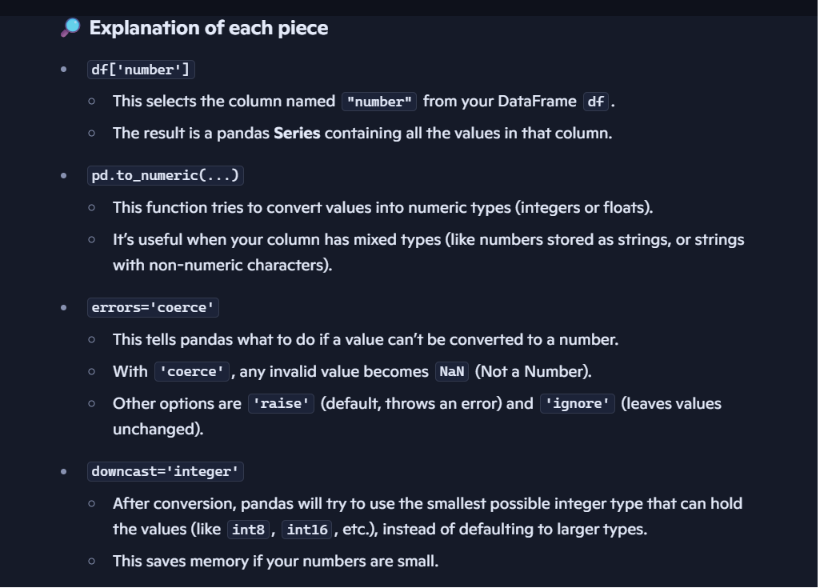
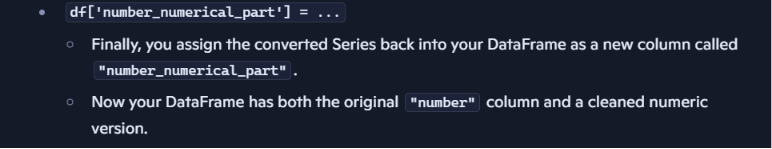

In [12]:
# extract categorical part
df['number_categorical_part'] = np.where(df['number_numerical_part'].isnull(),df['number'],np.nan)

df.head()

,Cabin,Ticket,number,Survived,number_numerical_part,number_categorical_part
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


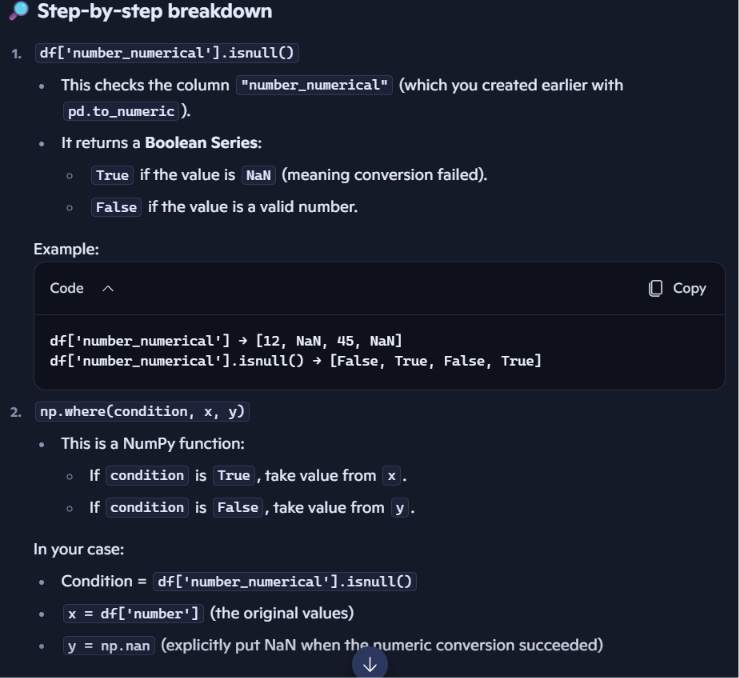
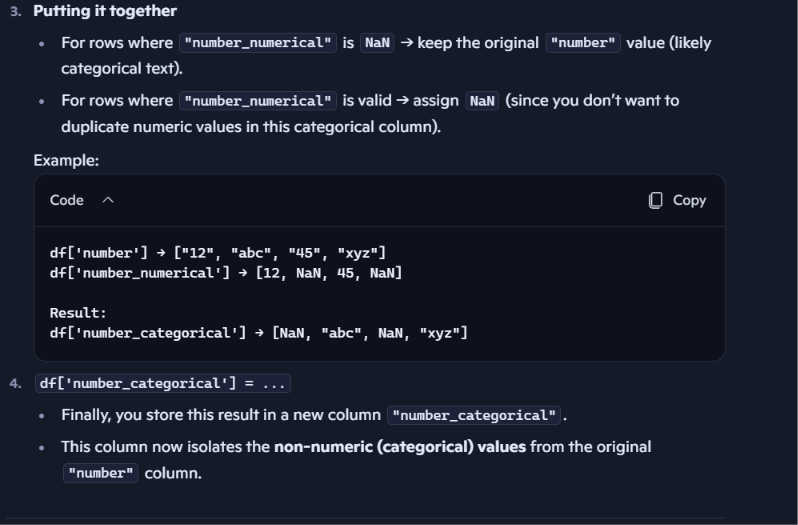

In [13]:
df['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [14]:
df['Ticket'].unique()

<StringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 681, dtype: str

now , we are dealing with the Cabin dataset

In [19]:
df['cabin_num']= df['Cabin'].str.extract(r'(\d+)') # captures numerical part
df['cabin_cat'] = df['Cabin'].str[0] # captures the first letter

df.head()

#we have written r in line 1 as it waas reading \d as end line character, to prevent that 
# we have decided that we take the whole as raw text. so, we used the r

,Cabin,Ticket,number,Survived,number_numerical_part,number_categorical_part,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


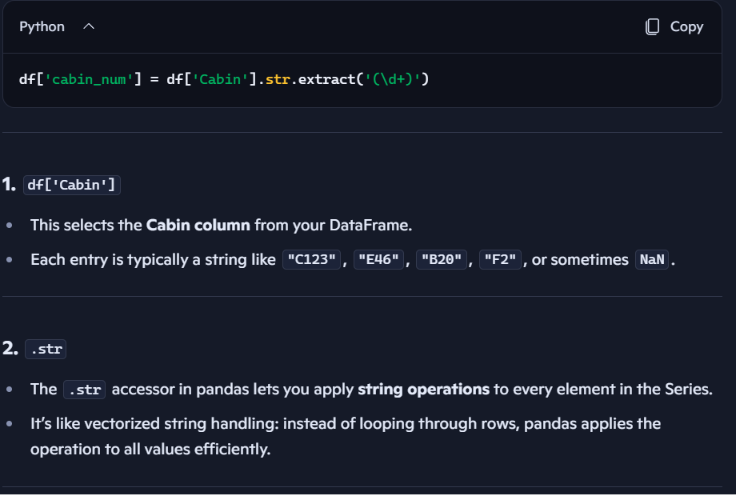
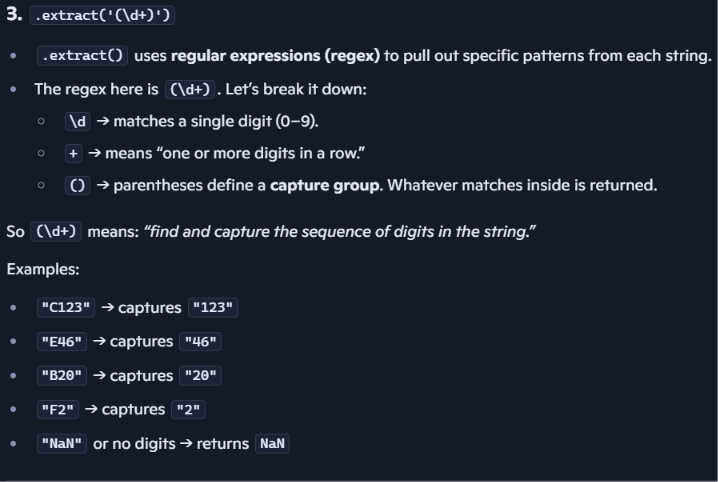
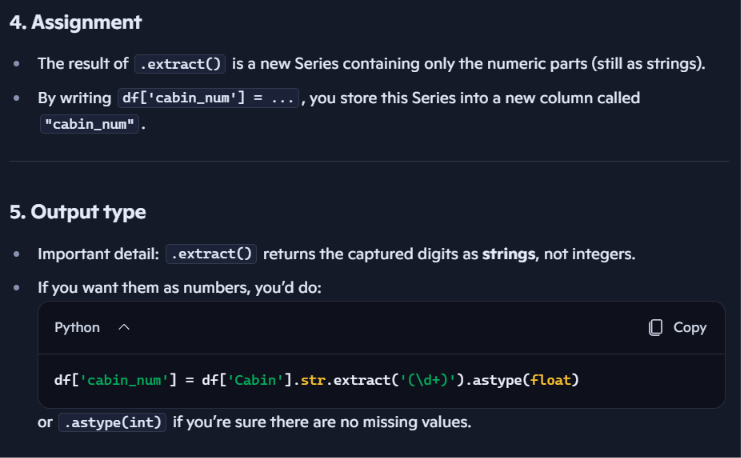

In [20]:
df['cabin_cat'].value_counts()

cabin_cat
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

<Axes: xlabel='cabin_cat'>

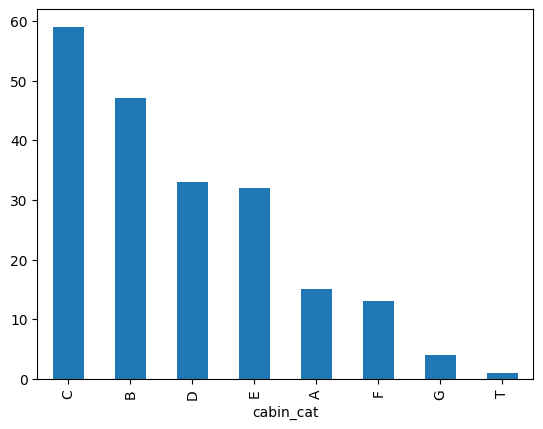

In [22]:
df['cabin_cat'].value_counts().plot(kind='bar')

In [24]:
# extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num' ] = pd.to_numeric(df['ticket_num'],
errors='coerce',
downcast='integer')

# extract the first part of ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan,
df['ticket_cat'])

df.head(5)

,Cabin,Ticket,number,Survived,number_numerical_part,number_categorical_part,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
